# Caio Vasconcelos Silva Andrade

## Notebook --> PSO & DE (Notas pessoais)

### Uma Meta-heurística Inspirada na Comportamento Coletivo e Evolução Diferencial

Este notebook é dedicado ao estudo dos **Algoritmos de meta-heurísticas inspirados em Comportamento Coletivo e Evolução Diferencial**. 

Diferente de estratégias baseadas em evolução genética tradicional, estas técnicas possuem mecanismos únicos de exploração do espaço de busca:

### Particle Swarm Optimization (PSO)

Inspirado no comportamento coletivo de bandos de pássaros PSO:

* Trabalha com uma população de partículas que navegam pelo espaço de busca
* Cada partícula ajusta sua trajetória baseando-se em:
    * Sua melhor experiência individual
    * A melhor experiência do coletivo

Utiliza velocidade e inércia para direcionar a exploração (Ainda não entendi muito isso aqui)

### Differential Evolution (DE)

Foca em estratégias de mutação baseadas em diferenças entre soluções:

Opera através de operadores específicos:

* Mutação diferencial: Gera novos vetores combinando diferenças entre indivíduos
* Recombinação: Mistura componentes de vetores-mutação com vetores-alvo
* Seleção competitiva: Substitui a geração atual apenas se houver melhoria

### Base do PSO: https://medium.com/data-science/what-the-hell-is-particle-swarm-optimization-pso-simplest-explanation-in-python-be296fc3b1ab
### Base do Parameters para PSO: https://www.researchgate.net/profile/Mohamed-Mourad-Lafifi/post/Which-is-the-best-swarm-size-in-PSO/attachment/5b5b6f85b53d2f89289c14e1/AS%3A653084896288769%401532718981208/download/Good+Parameters+for+Particle+Swarm+Optimization.pdf

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import random

## Sphere e Ackley

In [18]:
class Sphere:
    def __init__(self, n_var=10):
        self.n_var = n_var
        self.bounds = [-100, 100]
        
    def evaluate2(self, x):
        return np.sum(x**2)

    def evaluate(self, x):
        return np.sum((x - 0.5) ** 2)
    
class Ackley:
    def __init__(self, n_var=2, a=20, b=0.2, c=2*np.pi):
        self.n_var = n_var
        self.a = a
        self.b = b
        self.c = c
        self.bounds = [-100, 100]  # Domínio típico da função Ackley

    def evaluate(self, x):
        """Calcula o valor da função Ackley para um ponto x"""
        # Para lidar com múltiplos pontos (matriz) ou um único ponto (vetor)
        if x.ndim == 1:
            x = x.reshape(1, -1)
            
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(self.c * x))
        
        term1 = -self.a * np.exp(-self.b * np.sqrt(sum_sq / self.n_var))
        term2 = -np.exp(sum_cos / self.n_var)
        
        return term1 + term2 + self.a + np.exp(1)


In [19]:
# Criando instâncias dos problemas exemplo
sphere_2d = Sphere(n_var=2)
ackley_2d = Ackley(n_var=2)

In [20]:
# 2. Gerar dados para o gráfico da Sphere
x_s = np.linspace(-10, 10, 200)
y_s = np.linspace(-10, 10, 200)
X_s, Y_s = np.meshgrid(x_s, y_s)
# Calcula o Z avaliando cada ponto individualmente
Z_s = np.array([[sphere_2d.evaluate(np.array([x, y])) for x in x_s] for y in y_s])

# 3. Gerar dados para o gráfico da Ackley
# Usamos um intervalo maior para ver a "bacia" central e a área externa
x_a = np.linspace(-32, 32, 200)
y_a = np.linspace(-32, 32, 200)
X_a, Y_a = np.meshgrid(x_a, y_a)
# Calcula o Z avaliando cada ponto individualmente
Z_a = np.array([[ackley_2d.evaluate(np.array([x, y])) for x in x_a] for y in y_a])

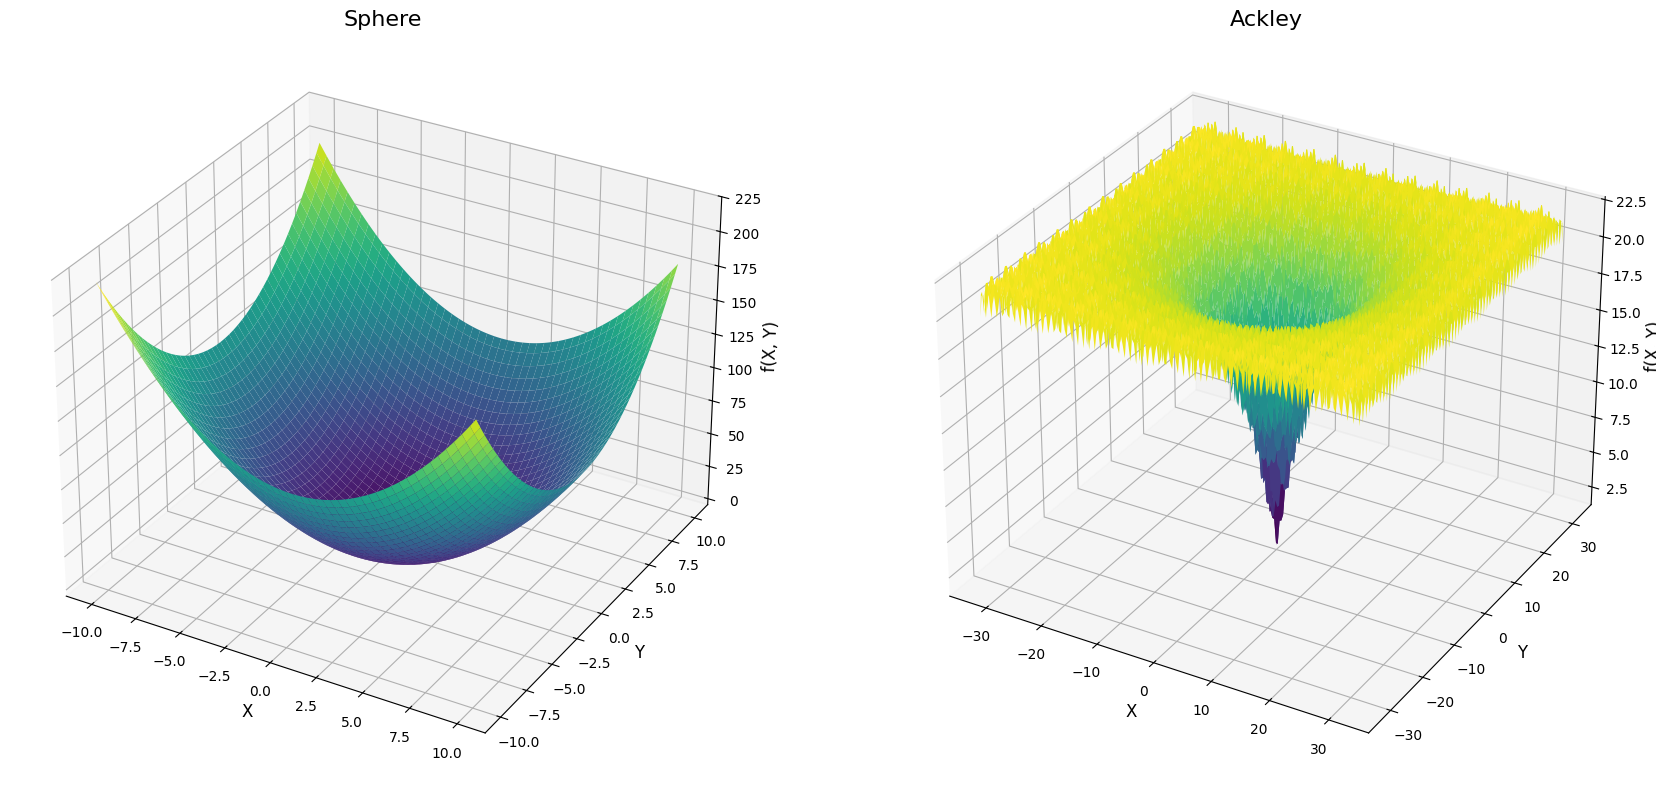

In [21]:
fig = plt.figure(figsize=(18, 8))

# Subplot para a Sphere
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_s, Y_s, Z_s, cmap='viridis', edgecolor='none')
ax1.set_title('Sphere', fontsize=16)
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_zlabel('f(X, Y)', fontsize=12)

# Subplot para a Ackley
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_a, Y_a, Z_a, cmap='viridis', edgecolor='none')
ax2.set_title('Ackley', fontsize=16)
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_zlabel('f(X, Y)', fontsize=12)

plt.tight_layout()
plt.show()

---------
# PSO & DE Algorithms
## Acabei escolhendo o PSO
### Eu achei esse artigo que usei como base para os parametros! [LINK](https://www.researchgate.net/profile/Mohamed-Mourad-Lafifi/post/Which-is-the-best-swarm-size-in-PSO/attachment/5b5b6f85b53d2f89289c14e1/AS%3A653084896288769%401532718981208/download/Good+Parameters+for+Particle+Swarm+Optimization.pdf)

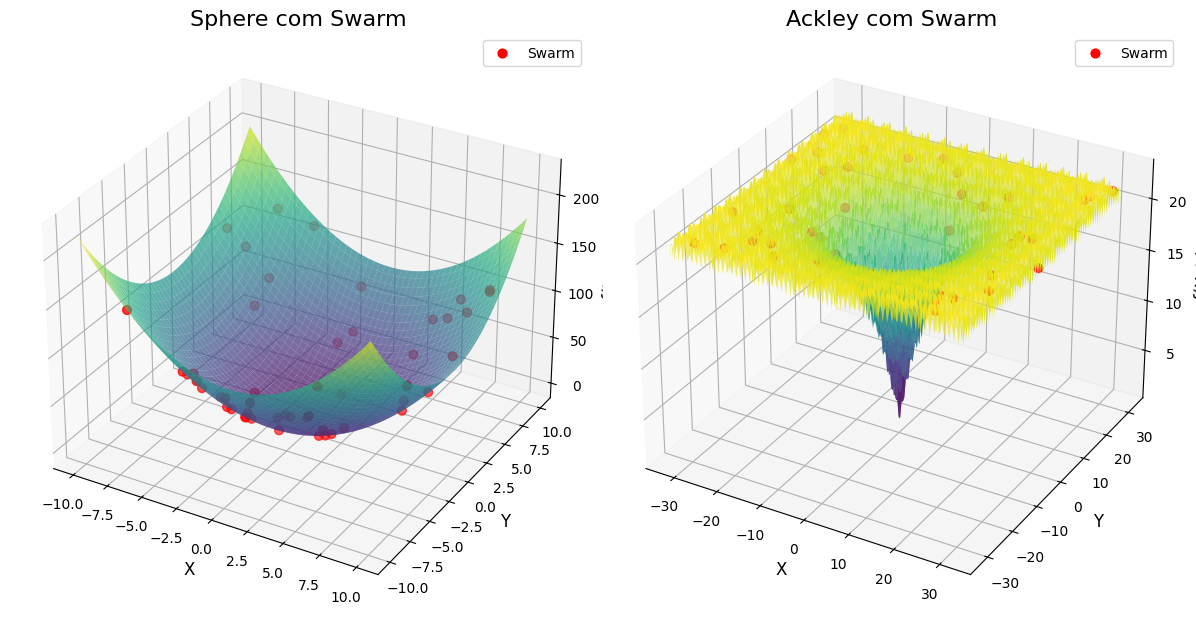

In [22]:
# Gerar o enxame (pontos aleatórios)
n_particles = 50
# Para a Sphere, no intervalo [-10, 10]
swarm_s_x = np.random.uniform(-10, 10, n_particles)
swarm_s_y = np.random.uniform(-10, 10, n_particles)
swarm_s_z = np.array([sphere_2d.evaluate(np.array([x, y])) for x, y in zip(swarm_s_x, swarm_s_y)])

# Para a Ackley, no intervalo [-32, 32]
swarm_a_x = np.random.uniform(-32, 32, n_particles)
swarm_a_y = np.random.uniform(-32, 32, n_particles)
swarm_a_z = np.array([ackley_2d.evaluate(np.array([x, y])) for x, y in zip(swarm_a_x, swarm_a_y)])

# 2. Plotar novamente com o enxame
fig = plt.figure(figsize=(12, 8))

# Subplot para a Sphere com enxame
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_s, Y_s, Z_s, cmap='viridis', edgecolor='none', alpha=0.7)
ax1.scatter(swarm_s_x, swarm_s_y, swarm_s_z, color='red', s=40, label='Swarm')
ax1.set_title('Sphere com Swarm', fontsize=16)
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_zlabel('f(X, Y)', fontsize=12)
ax1.legend()

# Subplot para a Ackley com enxame
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_a, Y_a, Z_a, cmap='viridis', edgecolor='none', alpha=0.7)
ax2.scatter(swarm_a_x, swarm_a_y, swarm_a_z, color='red', s=40, label='Swarm')
ax2.set_title('Ackley com Swarm', fontsize=16)
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_zlabel('f(X, Y)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

In [23]:
def create_random_individual(dim, min_val, max_val):
    return np.random.uniform(min_val, max_val, dim)

In [24]:
def particle_swarm_optimization(problem, n_particles=30, max_evals=50000, w=0.7, c1=1.5, c2=1.5):
    
    dim = problem.n_var
    min_val, max_val = problem.bounds
    eval_count = 0
    
    # Inicializa posições e velocidades das partículas
    positions = np.array([create_random_individual(dim, min_val, max_val) for _ in range(n_particles)])
    velocities = np.random.uniform(-abs(max_val - min_val) * 0.1, 
                                   abs(max_val - min_val) * 0.1, 
                                   (n_particles, dim))
    
    # Avalia posições iniciais
    fitness = np.array([problem.evaluate(pos) for pos in positions])
    eval_count += n_particles
    
    # Inicializa melhores posições individuais (pbest)
    pbest_positions = positions.copy()
    pbest_fitness = fitness.copy()
    
    # Inicializa melhor posição global (gbest)
    gbest_idx = np.argmin(pbest_fitness)
    gbest_position = pbest_positions[gbest_idx].copy()
    gbest_fitness = pbest_fitness[gbest_idx]
    
    # Loop principal
    while eval_count < max_evals:
        for i in range(n_particles):
            # Componentes aleatórios
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)
            
            # Atualiza velocidade
            # v = w*v + c1*r1*(pbest - x) + c2*r2*(gbest - x)
            cognitive = c1 * r1 * (pbest_positions[i] - positions[i])
            social = c2 * r2 * (gbest_position - positions[i])
            velocities[i] = w * velocities[i] + cognitive + social
            
            # Atualiza posição
            positions[i] = positions[i] + velocities[i]
            
            # Aplica limites nas posições
            positions[i] = np.clip(positions[i], min_val, max_val)
            
            # Avalia nova posição
            current_fitness = problem.evaluate(positions[i])
            eval_count += 1
            
            # Atualiza pbest se necessário
            if current_fitness < pbest_fitness[i]:
                pbest_positions[i] = positions[i].copy()
                pbest_fitness[i] = current_fitness
                
                # Atualiza gbest se necessário
                if current_fitness < gbest_fitness:
                    gbest_position = positions[i].copy()
                    gbest_fitness = current_fitness
            
            if eval_count >= max_evals:
                break
    
    return gbest_position, gbest_fitness


In [25]:
# PSO para Sphere
sphere_pso = Sphere(n_var=10)
resultados_pso_sphere = []

for i in range(20):
    best_vector, best_value = particle_swarm_optimization(problem=sphere_pso, n_particles=30, max_evals=50000, w=0.7, c1=1.5, c2=1.5)
    resultados_pso_sphere.append(best_value)
    print(f"Rodada {i+1} tivemos um valor minimizado de {best_value:.5f}")

min_value = min(resultados_pso_sphere)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value:.5f} da rodada {resultados_pso_sphere.index(min_value) + 1}")


Rodada 1 tivemos um valor minimizado de 0.00000
Rodada 2 tivemos um valor minimizado de 0.00000
Rodada 3 tivemos um valor minimizado de 0.00000
Rodada 4 tivemos um valor minimizado de 0.00000
Rodada 5 tivemos um valor minimizado de 0.00000
Rodada 6 tivemos um valor minimizado de 0.00000
Rodada 7 tivemos um valor minimizado de 0.00000
Rodada 8 tivemos um valor minimizado de 0.00000
Rodada 9 tivemos um valor minimizado de 0.00000
Rodada 10 tivemos um valor minimizado de 0.00000
Rodada 11 tivemos um valor minimizado de 0.00000
Rodada 12 tivemos um valor minimizado de 0.00000
Rodada 13 tivemos um valor minimizado de 0.00000
Rodada 14 tivemos um valor minimizado de 0.00000
Rodada 15 tivemos um valor minimizado de 0.00000
Rodada 16 tivemos um valor minimizado de 0.00000
Rodada 17 tivemos um valor minimizado de 0.00000
Rodada 18 tivemos um valor minimizado de 0.00000
Rodada 19 tivemos um valor minimizado de 0.00000
Rodada 20 tivemos um valor minimizado de 0.00000

O melhor valor minimizado qu

In [26]:
# PSO para Ackley
ackley_pso = Ackley(n_var=10)
resultados_pso_ackley = []

for i in range(20):
    best_vector, best_value = particle_swarm_optimization(problem=ackley_pso, n_particles=90, max_evals=50000, w=0.6571, c1=1.6319, c2=0.6239)
    resultados_pso_ackley.append(best_value)
    print(f"Rodada {i+1} tivemos um valor minimizado de {best_value:.5f}")

min_value = min(resultados_pso_ackley)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value:.5f} da rodada {resultados_pso_ackley.index(min_value) + 1}")


Rodada 1 tivemos um valor minimizado de 20.00000
Rodada 2 tivemos um valor minimizado de 0.00000
Rodada 3 tivemos um valor minimizado de 0.00000
Rodada 4 tivemos um valor minimizado de 20.13947
Rodada 5 tivemos um valor minimizado de 0.00000
Rodada 6 tivemos um valor minimizado de 0.00000
Rodada 7 tivemos um valor minimizado de 20.07228
Rodada 8 tivemos um valor minimizado de 0.00000
Rodada 9 tivemos um valor minimizado de 0.00000
Rodada 10 tivemos um valor minimizado de 1.15515
Rodada 11 tivemos um valor minimizado de 1.15515
Rodada 12 tivemos um valor minimizado de 20.13010
Rodada 13 tivemos um valor minimizado de 20.24028
Rodada 14 tivemos um valor minimizado de 20.36289
Rodada 15 tivemos um valor minimizado de 0.00000
Rodada 16 tivemos um valor minimizado de 20.00347
Rodada 17 tivemos um valor minimizado de 0.00000
Rodada 18 tivemos um valor minimizado de 0.00000
Rodada 19 tivemos um valor minimizado de 0.00000
Rodada 20 tivemos um valor minimizado de 1.64622

O melhor valor minimi

## Resultados
1. O PSO chegou sempre a 0 no Sphere (Obviamente)

2. Ja no Ackley o processo foi um pouco mais curioso!

    2.1 O parameters que usei foram de um artigo que achei sobre os melhores parametros para PSO a depender de alguns fatores (Como dimensão do seu problema) e com esses parametros ele consegui chegar a 0 varias vezes!

    2.2 Ja quando usei os parametros que usei "padrão" (Que usei no sphere) ele raramente chegou a 0!
------------